# Cauchy Distribution

The **Cauchy distribution** looks like a Normal distribution with much heavier tails. It is the classic example of a distribution with **no finite mean or variance** — making it pathological from a classical statistics standpoint, but extremely useful for stress-testing robust methods.

| Property | Value |
|---|---|
| **Parameters** | $t$ (location), $s$ (scale, $s > 0$) |
| **Support** | $(-\infty,\, +\infty)$ |
| **PDF** | $\displaystyle f(x) = \frac{1}{\pi s\!\left[1 + \left(\dfrac{x - t}{s}\right)^{\!2}\right]}$ |
| **CDF** | $\displaystyle F(x) = \frac{1}{2} + \frac{1}{\pi}\arctan\!\left(\frac{x - t}{s}\right)$ |
| **Mean** | **Undefined** (integral diverges) |
| **Variance** | **Undefined** |
| **Median** | $t$ |
| **Mode** | $t$ |
| **Skewness** | $0$ (symmetric, but undefined in the classical sense) |
| **Kurtosis** | Undefined |
| **Parameter estimation** | MLE or sample median (not sample mean — it doesn't converge) |

> **Key insight**: collecting 1 000 data points gives no more accurate an estimate of the mean than a single point — the sample mean does not converge.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Visualising the Cauchy Distribution

### Probability Density Function (PDF)

$$f(x \mid t, s) = \frac{1}{\pi s\!\left[1 + \left(\dfrac{x-t}{s}\right)^{\!2}\right]}$$

- The peak is at $x = t$ (location parameter), with height $\tfrac{1}{\pi s}$.
- A smaller scale $s$ gives a taller, narrower peak but the tails decay only as $\sim \tfrac{1}{x^2}$ — far slower than the Gaussian $e^{-x^2}$.
- The first panel overlays Cauchy and Normal PDFs; note that Cauchy has a **higher peak yet fatter tails** than Normal(0,1).

---

### Log-scale PDF — Tail Comparison

The second panel shows both PDFs on a **logarithmic density axis** to make the tail behaviour visible:

- Normal tails drop off exponentially (straight downward curve on log scale).
- Cauchy tails remain substantially elevated — this is the signature of an **algebraically heavy tail** ($\sim x^{-2}$).

---

### Sample Mean vs Sample Size (Non-Convergence)

The third panel demonstrates that the **Law of Large Numbers fails** for the Cauchy:

- The running mean of a Normal sample converges quickly to $0$.
- The Cauchy running mean wanders wildly and **never settles**, because each new observation can be arbitrarily large with non-negligible probability.


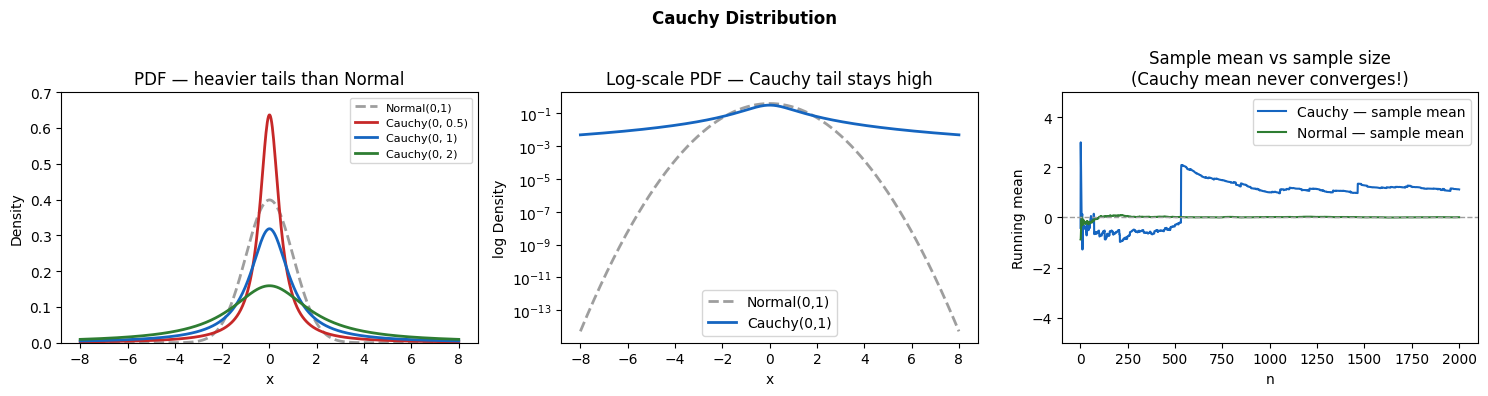

In [2]:
x = np.linspace(-8, 8, 600)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Cauchy Distribution', fontsize=12, fontweight='bold')

# PDF vs Normal
axes[0].plot(x, stats.norm(0, 1).pdf(x), color='#9E9E9E', linewidth=2, linestyle='--', label='Normal(0,1)')
for s, color, label in [(0.5, '#C62828', 'Cauchy(0, 0.5)'),
                         (1,   '#1565C0', 'Cauchy(0, 1)'),
                         (2,   '#2E7D32', 'Cauchy(0, 2)')]:
    axes[0].plot(x, stats.cauchy(0, s).pdf(x), color=color, linewidth=2, label=label)
axes[0].set_title('PDF — heavier tails than Normal')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 0.7)
axes[0].legend(fontsize=8)

# Heavy tail comparison (log scale)
axes[1].semilogy(x, stats.norm(0, 1).pdf(x), color='#9E9E9E', linewidth=2, linestyle='--', label='Normal(0,1)')
axes[1].semilogy(x, stats.cauchy(0, 1).pdf(x), color='#1565C0', linewidth=2, label='Cauchy(0,1)')
axes[1].set_title('Log-scale PDF — Cauchy tail stays high')
axes[1].set_xlabel('x'); axes[1].set_ylabel('log Density')
axes[1].legend()

# Sample mean does NOT converge (law of large numbers fails)
np.random.seed(42)
n_max = 2000
cauchy_data = stats.cauchy.rvs(size=n_max)
normal_data = stats.norm.rvs(size=n_max)
ns = np.arange(1, n_max+1)
axes[2].plot(ns, np.cumsum(cauchy_data)/ns, color='#1565C0', linewidth=1.5, label='Cauchy — sample mean')
axes[2].plot(ns, np.cumsum(normal_data)/ns, color='#2E7D32', linewidth=1.5, label='Normal — sample mean')
axes[2].axhline(0, color='#9E9E9E', linewidth=1, linestyle='--')
axes[2].set_title('Sample mean vs sample size\n(Cauchy mean never converges!)')
axes[2].set_xlabel('n'); axes[2].set_ylabel('Running mean')
axes[2].set_ylim(-5, 5)
axes[2].legend()

plt.tight_layout()
plt.show()

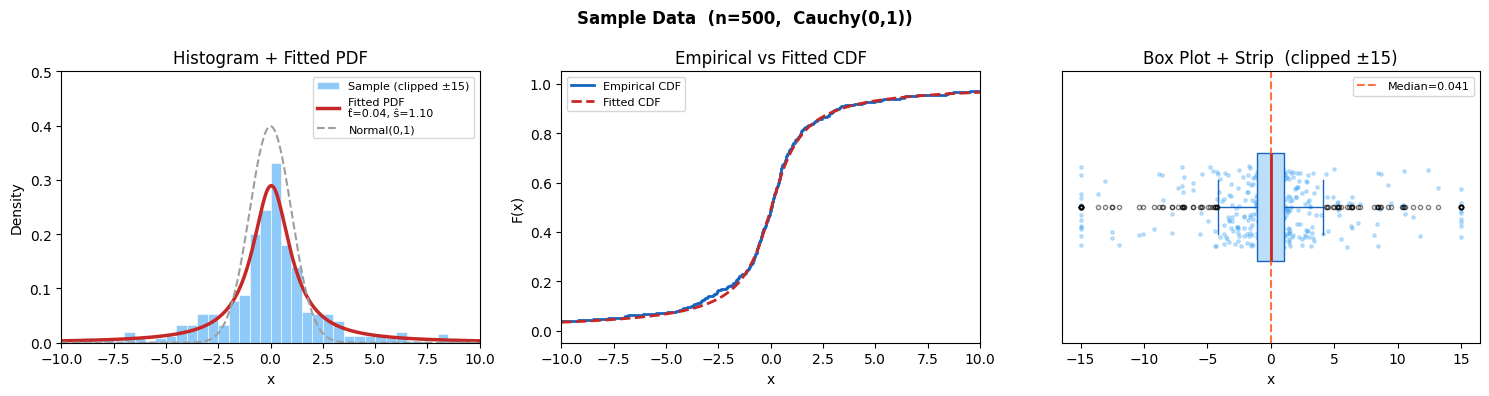

Sample: n=500,  median=0.0414,  IQR=2.0956,  outliers beyond ±15: 20
Note: mean and std are not reported — they are undefined for the Cauchy distribution.


In [3]:
# Sample data plots — Cauchy(0, 1)
np.random.seed(42)
sample_c = stats.cauchy.rvs(loc=0, scale=1, size=500)
# clip for display only — Cauchy has extreme outliers
clip = 15
t_hat, s_hat = stats.cauchy.fit(sample_c)
x_fit = np.linspace(-10, 10, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sample Data  (n=500,  Cauchy(0,1))', fontsize=12, fontweight='bold')

# ── Histogram + fitted PDF ───────────────────────────────────────────────────
axes[0].hist(np.clip(sample_c, -clip, clip), bins=60, density=True,
             color='#90CAF9', edgecolor='white', linewidth=0.4, label='Sample (clipped ±15)')
axes[0].plot(x_fit, stats.cauchy(t_hat, s_hat).pdf(x_fit),
             color='#C62828', linewidth=2.5, label=f'Fitted PDF\nt̂={t_hat:.2f}, ŝ={s_hat:.2f}')
axes[0].plot(x_fit, stats.norm(0, 1).pdf(x_fit),
             color='#9E9E9E', linewidth=1.5, linestyle='--', label='Normal(0,1)')
axes[0].set_xlim(-10, 10); axes[0].set_ylim(0, 0.5)
axes[0].set_title('Histogram + Fitted PDF')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# ── Empirical CDF vs fitted CDF ──────────────────────────────────────────────
sorted_c = np.sort(sample_c)
ecdf = np.arange(1, len(sorted_c) + 1) / len(sorted_c)
axes[1].step(np.clip(sorted_c, -clip, clip), ecdf, color='#1565C0', linewidth=2, label='Empirical CDF')
axes[1].plot(x_fit, stats.cauchy(t_hat, s_hat).cdf(x_fit),
             color='#C62828', linewidth=2, linestyle='--', label='Fitted CDF')
axes[1].set_xlim(-10, 10)
axes[1].set_title('Empirical vs Fitted CDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend(fontsize=8)

# ── Box plot + strip (heavy outliers visible) ────────────────────────────────
sample_disp = np.clip(sample_c, -clip, clip)
axes[2].boxplot(sample_disp, vert=False, patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='#BBDEFB', color='#1565C0'),
                medianprops=dict(color='#C62828', linewidth=2),
                whiskerprops=dict(color='#1565C0'),
                capprops=dict(color='#1565C0'),
                flierprops=dict(marker='o', color='#FF7043', markersize=3, alpha=0.5))
axes[2].scatter(sample_disp, np.random.uniform(0.85, 1.15, len(sample_disp)),
                color='#42A5F5', s=6, alpha=0.3)
axes[2].axvline(np.median(sample_c), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_c):.3f}')
axes[2].set_title('Box Plot + Strip  (clipped ±15)')
axes[2].set_xlabel('x'); axes[2].set_yticks([])
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

n_out = np.sum(np.abs(sample_c) > clip)
print(f"Sample: n={len(sample_c)},  median={np.median(sample_c):.4f},  "
      f"IQR={stats.iqr(sample_c):.4f},  outliers beyond ±{clip}: {n_out}")
print("Note: mean and std are not reported — they are undefined for the Cauchy distribution.")


## Key Takeaways

| | |
|---|---|
| **No mean/variance** | All moments are undefined — the sample mean never converges |
| **Heavy tails** | Tail decays as $\sim 1/x^2$ vs Normal's $e^{-x^2}$ — extreme values are far more likely |
| **Symmetric** | Median $=$ mode $=$ location $t$; visually looks like a fat Normal |
| **Pathological** | Law of Large Numbers and CLT do not apply |
| **Robustness testing** | Used to stress-test procedures under heavy-tailed contamination |
| **Use median** | Sample median is a consistent estimator of $t$; sample mean is not |
| **Physics** | Models resonance phenomena and ratio of two independent $\mathcal{N}(0,1)$ variables |
